# 05_comparison — LSTM vs. XGBoost, FD001 & FD003

**Protocol:** `README.md` v1.0 — Notebook 5 of 5. **Analysis only: trains nothing, mutates no model.**
Reads the saved outputs of `01_LSTM_FD001`, `02_LSTM_FD003`, `03_XGB_FD001`, `04_XGB_FD003`
(`summary.json`, `metrics_per_seed.csv`, `predictions.csv`, `fingerprint.json`, `config.json`) and
produces the master comparison tables, statistical tests, efficiency comparison, and figures for the paper.

Run this only after all four experiment notebooks have finished and their fingerprints have been
cross-checked (README section 5). This notebook re-verifies that check before comparing anything.

## C1 — Environment & paths

In [ ]:
# C1 — Environment & paths
!pip install -q tabulate
import os, json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003"
RESULTS_ROOT = os.path.join(BASE_DIR, "results")
COMPARISON_DIR = os.path.join(RESULTS_ROOT, "comparison")
os.makedirs(COMPARISON_DIR, exist_ok=True)

COMBOS = {
    ("LSTM", "FD001"): os.path.join(RESULTS_ROOT, "LSTM_FD001"),
    ("LSTM", "FD003"): os.path.join(RESULTS_ROOT, "LSTM_FD003"),
    ("XGB",  "FD001"): os.path.join(RESULTS_ROOT, "XGB_FD001"),
    ("XGB",  "FD003"): os.path.join(RESULTS_ROOT, "XGB_FD003"),
}

for (model, ds), path in COMBOS.items():
    assert os.path.isdir(path), f"Missing results folder for {model}/{ds}: {path}"
print("All four results folders found.")
for (model, ds), path in COMBOS.items():
    print(f"  {model:5s} {ds}: {sorted(os.listdir(path))}")


Mounted at /content/drive
All four results folders found.
  LSTM  FD001: ['config.json', 'env.json', 'figures', 'fingerprint.json', 'metrics_per_seed.csv', 'models', 'predictions.csv', 'summary.json', 'training_log.json']
  LSTM  FD003: ['config.json', 'env.json', 'figures', 'fingerprint.json', 'metrics_per_seed.csv', 'models', 'predictions.csv', 'summary.json', 'training_log.json']
  XGB   FD001: ['config.json', 'env.json', 'figures', 'fingerprint.json', 'metrics_per_seed.csv', 'models', 'predictions.csv', 'summary.json', 'training_log.json']
  XGB   FD003: ['config.json', 'env.json', 'figures', 'fingerprint.json', 'metrics_per_seed.csv', 'models', 'predictions.csv', 'summary.json', 'training_log.json']


## C2 — Load saved artefacts

In [ ]:
# C2 — Load saved artefacts
def load_json(path):
    with open(path) as f:
        return json.load(f)

summaries    = {}
configs      = {}
fingerprints = {}
metrics_ps   = {}
predictions  = {}

for key, path in COMBOS.items():
    summaries[key]    = load_json(os.path.join(path, "summary.json"))
    configs[key]      = load_json(os.path.join(path, "config.json"))
    fingerprints[key] = load_json(os.path.join(path, "fingerprint.json"))
    metrics_ps[key]   = pd.read_csv(os.path.join(path, "metrics_per_seed.csv"))
    predictions[key]  = pd.read_csv(os.path.join(path, "predictions.csv"))

print("Loaded summary.json, config.json, fingerprint.json, metrics_per_seed.csv, predictions.csv")
print("for all four (model, dataset) combinations.")


Loaded summary.json, config.json, fingerprint.json, metrics_per_seed.csv, predictions.csv
for all four (model, dataset) combinations.


## C3 — Fingerprint validity gate (README section 5)

In [ ]:
# C3 — Fingerprint validity gate
# Per README: "The comparison notebook refuses to compare two runs of the same dataset
# whose fingerprints differ." Every array hash + the validation-engine hash must match
# between the LSTM and XGBoost run of the same dataset.
FIELDS_TO_CHECK = ["X_train", "y_train", "X_val", "y_val", "X_test",
                    "y_test_raw", "y_test_clipped", "val_engines_hash"]

mismatches = []
for dataset in ("FD001", "FD003"):
    fp_lstm = fingerprints[("LSTM", dataset)]
    fp_xgb  = fingerprints[("XGB", dataset)]
    for field in FIELDS_TO_CHECK:
        if fp_lstm[field] != fp_xgb[field]:
            mismatches.append((dataset, field, fp_lstm[field], fp_xgb[field]))

if mismatches:
    print("FINGERPRINT MISMATCH — the LSTM and XGBoost runs did NOT use identical data:")
    for dataset, field, a, b in mismatches:
        print(f"  [{dataset}] {field}: LSTM={a}  XGB={b}")
    raise AssertionError(
        "Fingerprints differ between LSTM and XGBoost on the same dataset. "
        "Re-run the affected notebook(s) before comparing results (README section 5)."
    )

print("Fingerprint check passed: LSTM and XGBoost used byte-identical data on both FD001 and FD003.")


Fingerprint check passed: LSTM and XGBoost used byte-identical data on both FD001 and FD003.


## C4 — Master comparison table (primary target: RUL clipped at 125)

In [ ]:
# C4 — Master comparison table
rows = []
for (model, dataset), summ in summaries.items():
    s = summ["summary_metrics"]
    rows.append({
        "model": model,
        "dataset": dataset,
        "rmse_mean": s["primary_rmse"]["mean"], "rmse_std": s["primary_rmse"]["std"],
        "mae_mean": s["primary_mae"]["mean"], "mae_std": s["primary_mae"]["std"],
        "nasa_score_mean": s["primary_nasa_score"]["mean"], "nasa_score_std": s["primary_nasa_score"]["std"],
        "within_5_mean": s["primary_within_5"]["mean"],
        "within_10_mean": s["primary_within_10"]["mean"],
        "within_15_mean": s["primary_within_15"]["mean"],
    })

master_table = pd.DataFrame(rows).sort_values(["dataset", "model"]).reset_index(drop=True)
print(master_table.round(3).to_string(index=False))

master_table.to_csv(os.path.join(COMPARISON_DIR, "master_comparison_primary.csv"), index=False)


model dataset  rmse_mean  rmse_std  mae_mean  mae_std  nasa_score_mean  nasa_score_std  within_5_mean  within_10_mean  within_15_mean
 LSTM   FD001     14.209     0.939    10.253    0.798          457.902         129.917          0.394           0.607           0.754
  XGB   FD001     13.267     0.384    10.212    0.410          291.288          21.573          0.342           0.586           0.762
 LSTM   FD003     14.199     0.680     9.795    0.685          818.447         231.708          0.436           0.655           0.772
  XGB   FD003     14.744     0.221    10.867    0.262          516.141          30.948          0.374           0.585           0.702


## C5 — Secondary target (official unclipped RUL) — reported for completeness

In [ ]:
# C5 — Secondary target table
rows_secondary = []
for (model, dataset), summ in summaries.items():
    s = summ["summary_metrics"]
    rows_secondary.append({
        "model": model, "dataset": dataset,
        "rmse_mean": s["secondary_rmse"]["mean"], "rmse_std": s["secondary_rmse"]["std"],
        "mae_mean": s["secondary_mae"]["mean"], "mae_std": s["secondary_mae"]["std"],
        "nasa_score_mean": s["secondary_nasa_score"]["mean"], "nasa_score_std": s["secondary_nasa_score"]["std"],
    })
secondary_table = pd.DataFrame(rows_secondary).sort_values(["dataset", "model"]).reset_index(drop=True)
print(secondary_table.round(3).to_string(index=False))
secondary_table.to_csv(os.path.join(COMPARISON_DIR, "master_comparison_secondary.csv"), index=False)


model dataset  rmse_mean  rmse_std  mae_mean  mae_std  nasa_score_mean  nasa_score_std
 LSTM   FD001     15.279     0.818    11.322    0.797          487.952         126.715
  XGB   FD001     14.583     0.379    11.282    0.410          326.089          22.191
 LSTM   FD003     15.526     0.595    11.349    0.683          854.472         229.620
  XGB   FD003     16.252     0.215    12.424    0.261          559.933          30.627


## C6 — Statistical comparison (paired bootstrap CI + Wilcoxon, per README section 8)

In [ ]:
# C6 — Statistical comparison
def per_engine_table(model, dataset):
    df = predictions[(model, dataset)][["engine_id", "y_true_clipped", "y_pred_mean"]].copy()
    df = df.sort_values("engine_id").reset_index(drop=True)
    df["abs_err"] = (df["y_pred_mean"] - df["y_true_clipped"]).abs()
    return df

def bootstrap_delta_rmse(err_a, err_b, n_boot=10000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(err_a)
    deltas = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        rmse_a = np.sqrt(np.mean(err_a[idx] ** 2))
        rmse_b = np.sqrt(np.mean(err_b[idx] ** 2))
        deltas[i] = rmse_a - rmse_b
    return deltas

stat_rows = []
for dataset in ("FD001", "FD003"):
    lstm_df = per_engine_table("LSTM", dataset)
    xgb_df  = per_engine_table("XGB", dataset)
    assert (lstm_df["engine_id"].to_numpy() == xgb_df["engine_id"].to_numpy()).all(), (
        f"Engine ID mismatch between LSTM and XGB predictions on {dataset}."
    )

    err_lstm = (lstm_df["y_pred_mean"] - lstm_df["y_true_clipped"]).to_numpy()
    err_xgb  = (xgb_df["y_pred_mean"]  - xgb_df["y_true_clipped"]).to_numpy()

    deltas = bootstrap_delta_rmse(err_lstm, err_xgb, n_boot=10000, seed=0)
    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])
    point_delta = np.sqrt(np.mean(err_lstm ** 2)) - np.sqrt(np.mean(err_xgb ** 2))

    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(lstm_df["abs_err"], xgb_df["abs_err"])

    stat_rows.append({
        "dataset": dataset,
        "delta_rmse_lstm_minus_xgb": point_delta,
        "bootstrap_ci_low_2.5pct": ci_low,
        "bootstrap_ci_high_97.5pct": ci_high,
        "ci_excludes_zero": bool(ci_low > 0 or ci_high < 0),
        "wilcoxon_stat": wilcoxon_stat,
        "wilcoxon_p": wilcoxon_p,
    })

stat_table = pd.DataFrame(stat_rows)
print(stat_table.round(4).to_string(index=False))
print()
print("Reading guide: a 95% CI that excludes 0 means the RMSE difference between LSTM and XGBoost")
print("on that dataset is unlikely to be bootstrap noise. It does NOT by itself establish which")
print("model is 'better' in a broader sense — see README section 13 (Limitations).")

stat_table.to_csv(os.path.join(COMPARISON_DIR, "statistical_comparison.csv"), index=False)


dataset  delta_rmse_lstm_minus_xgb  bootstrap_ci_low_2.5pct  bootstrap_ci_high_97.5pct  ci_excludes_zero  wilcoxon_stat  wilcoxon_p
  FD001                     0.4594                  -0.8599                     1.7861             False         2178.0      0.2328
  FD003                    -1.2961                  -3.2102                     0.4721             False         1954.0      0.0496

Reading guide: a 95% CI that excludes 0 means the RMSE difference between LSTM and XGBoost
on that dataset is unlikely to be bootstrap noise. It does NOT by itself establish which
model is 'better' in a broader sense — see README section 13 (Limitations).


## C7 — Efficiency comparison

In [ ]:
# C7 — Efficiency comparison
eff_rows = []
for (model, dataset), summ in summaries.items():
    e = summ["efficiency"]
    row = {"model": model, "dataset": dataset,
           "model_size_kb": e["model_size_bytes_seed0"] / 1024,
           "mean_training_time_sec": e["mean_training_time_sec"],
           "cpu_latency_single_ms_median": e["cpu_latency_single_sample_ms"]["median"],
           "cpu_latency_single_ms_p95": e["cpu_latency_single_sample_ms"]["p95"],
           "cpu_latency_batch_per_sample_ms_median": e["cpu_latency_full_batch_per_sample_ms"]["median"]}
    if model == "LSTM":
        row["capacity"] = f'{e["trainable_parameters"]} parameters'
    else:
        row["capacity"] = f'{e["trees_used_seed0"]} trees / {e["total_nodes_seed0"]} nodes (seed 0)'
    eff_rows.append(row)

efficiency_table = pd.DataFrame(eff_rows).sort_values(["dataset", "model"]).reset_index(drop=True)
print(efficiency_table.round(3).to_string(index=False))

efficiency_table.to_csv(os.path.join(COMPARISON_DIR, "efficiency_comparison.csv"), index=False)


model dataset  model_size_kb  mean_training_time_sec  cpu_latency_single_ms_median  cpu_latency_single_ms_p95  cpu_latency_batch_per_sample_ms_median                          capacity
 LSTM   FD001        221.619                  13.738                         0.565                      0.876                                   0.072                  55873 parameters
  XGB   FD001       3998.872                   7.314                         0.079                      0.107                                   0.001 889 trees / 102529 nodes (seed 0)
 LSTM   FD003        221.619                  19.718                         0.806                      1.087                                   0.049                  55873 parameters
  XGB   FD003       4280.985                   7.521                         0.081                      0.111                                   0.001 974 trees / 109450 nodes (seed 0)


## C8 — Figures: predicted vs. true RUL (all four combinations)

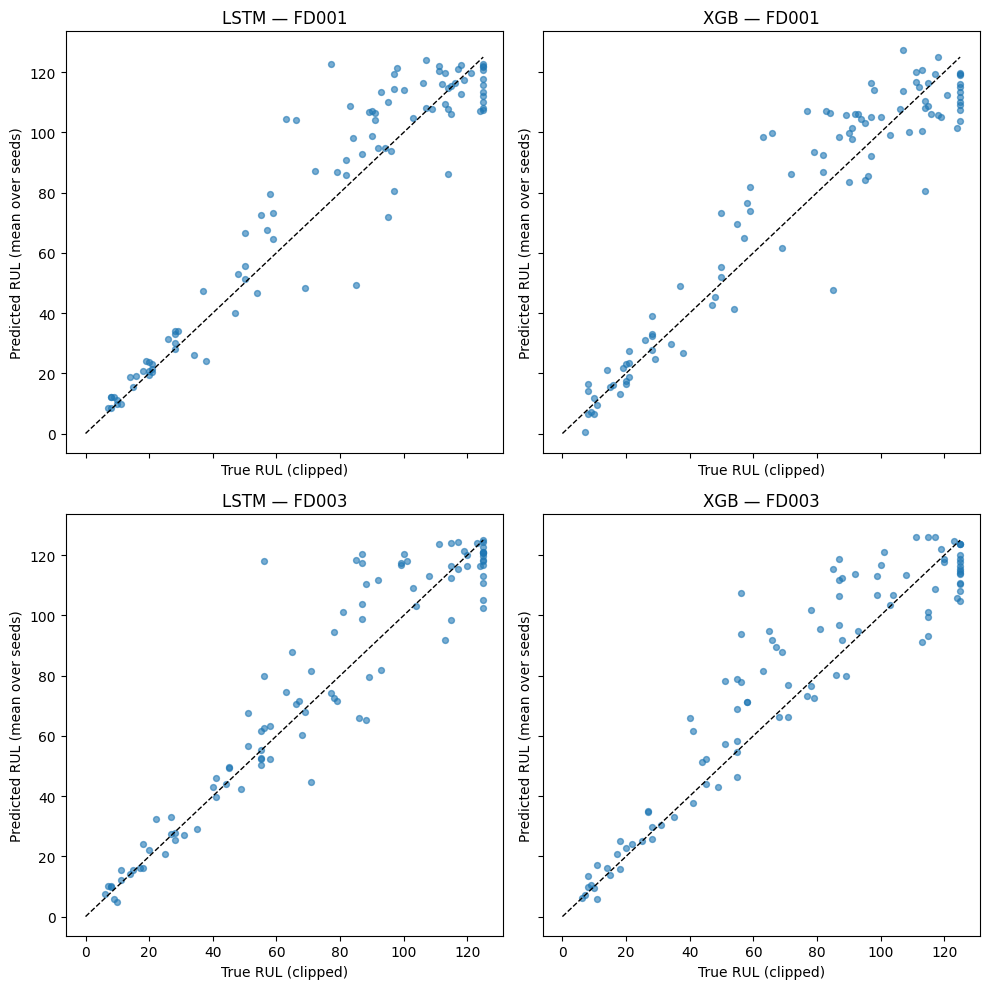

In [ ]:
# C8 — Predicted vs. true, 4-panel grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
panel_order = [("LSTM", "FD001"), ("XGB", "FD001"), ("LSTM", "FD003"), ("XGB", "FD003")]

for ax, (model, dataset) in zip(axes.flat, panel_order):
    df = predictions[(model, dataset)]
    ax.scatter(df["y_true_clipped"], df["y_pred_mean"], alpha=0.6, s=18)
    lims = [0, 125]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_title(f"{model} — {dataset}")
    ax.set_xlabel("True RUL (clipped)")
    ax.set_ylabel("Predicted RUL (mean over seeds)")

fig.tight_layout()
fig.savefig(os.path.join(COMPARISON_DIR, "pred_vs_true_grid.png"), dpi=300)
plt.show()


## C9 — Figure: RMSE distribution across seeds

/tmp/ipykernel_3779/2511029980.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=box_labels, showmeans=True)


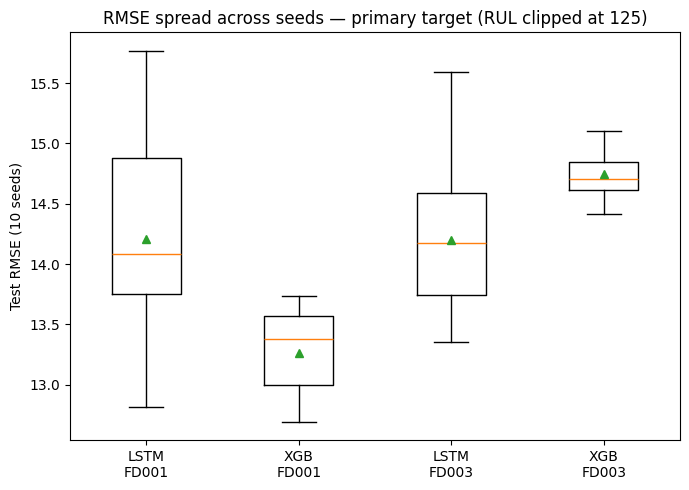

In [ ]:
# C9 — RMSE distribution across seeds (boxplot)
fig, ax = plt.subplots(figsize=(7, 5))
box_data, box_labels = [], []
for dataset in ("FD001", "FD003"):
    for model in ("LSTM", "XGB"):
        box_data.append(metrics_ps[(model, dataset)]["primary_rmse"].to_numpy())
        box_labels.append(f"{model}\n{dataset}")

ax.boxplot(box_data, labels=box_labels, showmeans=True)
ax.set_ylabel("Test RMSE (10 seeds)")
ax.set_title("RMSE spread across seeds — primary target (RUL clipped at 125)")
fig.tight_layout()
fig.savefig(os.path.join(COMPARISON_DIR, "rmse_boxplot.png"), dpi=300)
plt.show()


## C10 — Figure: CPU inference latency comparison

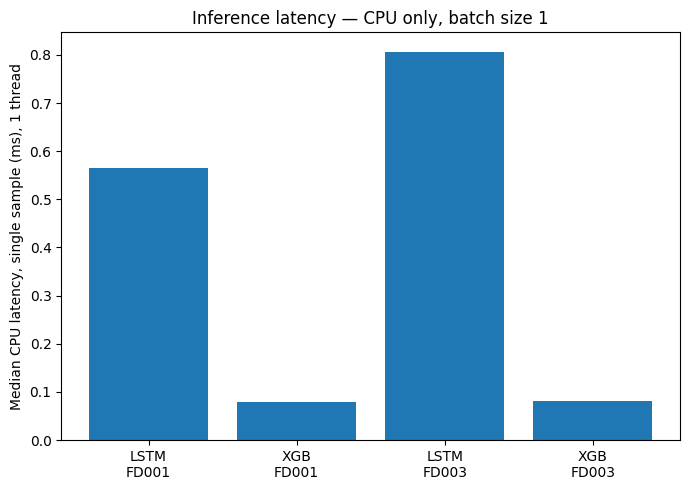

In [ ]:
# C10 — CPU inference latency comparison
fig, ax = plt.subplots(figsize=(7, 5))
labels = [f"{r.model}\n{r.dataset}" for r in efficiency_table.itertuples()]
values = efficiency_table["cpu_latency_single_ms_median"].to_numpy()
ax.bar(labels, values)
ax.set_ylabel("Median CPU latency, single sample (ms), 1 thread")
ax.set_title("Inference latency — CPU only, batch size 1")
fig.tight_layout()
fig.savefig(os.path.join(COMPARISON_DIR, "latency_comparison.png"), dpi=300)
plt.show()


## C11 — Export markdown tables (paste into the paper / README)

In [ ]:
# C11 — Export markdown tables
with open(os.path.join(COMPARISON_DIR, "tables_for_paper.md"), "w") as f:
    f.write("## Primary results (RUL clipped at 125), mean +/- std over 10 seeds\n\n")
    f.write(master_table.round(3).to_markdown(index=False))
    f.write("\n\n## Statistical comparison (paired bootstrap, 10,000 resamples; Wilcoxon signed-rank)\n\n")
    f.write(stat_table.round(4).to_markdown(index=False))
    f.write("\n\n## Efficiency comparison\n\n")
    f.write(efficiency_table.round(3).to_markdown(index=False))
    f.write("\n")

print("Markdown tables written to:", os.path.join(COMPARISON_DIR, "tables_for_paper.md"))
print(sorted(os.listdir(COMPARISON_DIR)))


Markdown tables written to: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/comparison/tables_for_paper.md
['efficiency_comparison.csv', 'latency_comparison.png', 'master_comparison_primary.csv', 'master_comparison_secondary.csv', 'pred_vs_true_grid.png', 'rmse_boxplot.png', 'statistical_comparison.csv', 'tables_for_paper.md']
